# Logistic Regression - BODMAS Malware Classification

## Algorithm Justification

Logistic Regression was selected as the first classifier for several reasons:

- **High-dimensional suitability:** BODMAS feature vectors are high-dimensional numerical representations of PE binaries. Logistic Regression with L2 regularisation handles this well by penalising large coefficients and preventing overfitting.
- **Interpretable baseline:** It provides a strong, interpretable linear baseline to compare against more complex models like Random Forest.
- **SAGA solver:** The `saga` solver supports multinomial (softmax) loss, making it directly applicable to this multi-class problem without decomposing into binary classifiers.
- **Class imbalance:** `class_weight='balanced'` automatically adjusts decision boundaries to account for the skewed class distribution in BODMAS, where benign samples dominate.

In [2]:
# ============================================================
# LOGISTIC REGRESSION
# ============================================================

import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import VarianceThreshold

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix
)

from google.colab import drive
drive.mount('/content/drive')

# Google Drive directory
PROJECT_DIR = "/content/drive/MyDrive/BODMAS_Assignment"

# PROJECT_DIR = r"/Users/varunsp/Developer/Applications of Artificial Intelligence for Cyber Security/PY/Assignment-2_Final"

DATA_DIR = os.path.join(PROJECT_DIR, "dataset")
OUTPUT_DIR = os.path.join(PROJECT_DIR, "logisticregression")

os.makedirs(OUTPUT_DIR, exist_ok=True)

BODMAS_NPZ = os.path.join(DATA_DIR, "bodmas.npz")
METADATA_CSV = os.path.join(DATA_DIR, "bodmas_metadata.csv")
CATEGORY_CSV = os.path.join(DATA_DIR, "bodmas_malware_category.csv")

RANDOM_STATE = 42
TEST_SIZE = 0.20

print("Data folder:", DATA_DIR)
print("Logistic Regression output folder:", OUTPUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data folder: /content/drive/MyDrive/BODMAS_Assignment/dataset
Logistic Regression output folder: /content/drive/MyDrive/BODMAS_Assignment/logisticregression


## Data Loading

The BODMAS dataset consists of three files:
- `bodmas.npz` - the pre-extracted numerical feature matrix `X`
- `bodmas_metadata.csv` - SHA256 hashes and file-level metadata for all samples
- `bodmas_malware_category.csv` - maps SHA256 hashes to malware family labels (malware only)

These are loaded separately and joined on the SHA256 column in the next step.

In [3]:
# ============================================================
# LOAD DATA AND PREPARE CATEGORY LABELS
# ============================================================

print("=" * 80)
print("LOADING DATA")
print("=" * 80)

data = np.load(BODMAS_NPZ, allow_pickle=True)
X = data["X"]

metadata = pd.read_csv(METADATA_CSV)
categories = pd.read_csv(CATEGORY_CSV)

print("NPZ keys:", list(data.keys()))
print("Feature matrix shape:", X.shape)
print("Metadata shape:", metadata.shape)
print("Category file shape:", categories.shape)

print("\nMetadata columns:", metadata.columns.tolist())
print("Category columns:", categories.columns.tolist())

# =========================
# Correct label preparation
# =========================
metadata_sha_col = "sha256" if "sha256" in metadata.columns else "sha"
category_sha_col = "sha256" if "sha256" in categories.columns else "sha"

possible_category_cols = [
    col for col in categories.columns
    if col.lower() not in ["sha", "sha256"]
]

category_label_col = possible_category_cols[0]

print("\nUsing metadata SHA column:", metadata_sha_col)
print("Using category SHA column:", category_sha_col)
print("Using malware category column:", category_label_col)

category_map = categories.set_index(category_sha_col)[category_label_col]

df = metadata.copy()
df["malware_category"] = df[metadata_sha_col].map(category_map)

# The Category CSV does not include benign samples
df["malware_category"] = df["malware_category"].fillna("benign")

y_text = df["malware_category"].astype(str).values

print("\nFinal X shape:", X.shape)
print("Final y shape:", y_text.shape)

print("\nClass distribution:")
class_distribution = pd.Series(y_text).value_counts()
display(class_distribution)

class_distribution.to_csv(os.path.join(OUTPUT_DIR, "lr_class_distribution.csv"))

LOADING DATA
NPZ keys: ['X', 'y']
Feature matrix shape: (134435, 2381)
Metadata shape: (134435, 3)
Category file shape: (57293, 2)

Metadata columns: ['sha', 'timestamp', 'family']
Category columns: ['sha256', 'category']

Using metadata SHA column: sha
Using category SHA column: sha256
Using malware category column: category

Final X shape: (134435, 2381)
Final y shape: (134435,)

Class distribution:


,count
benign,77142
trojan,29972
worm,16697
backdoor,7331
downloader,1031
ransomware,821
dropper,715
informationstealer,448
virus,192
pua,29


## Label Preparation

The category CSV only contains malware samples - benign samples are absent by design. Labels are assigned by joining metadata with the category file on SHA256. Any sample not found in the category file is filled as `"benign"`. This correctly reconstructs the full ground-truth label set without discarding any samples.

The code also auto-detects whether the SHA column is named `sha` or `sha256` to handle potential schema differences between the training and holdout files.

## Label Encoding and Train-Test Split

Class names (strings) are converted to integer indices using `LabelEncoder`. The encoder is saved to disk so the holdout evaluation uses identical class-to-index mappings without refitting.

An **80/20 stratified split** is used to ensure each malware family is proportionally represented in both train and test sets. `random_state=42` ensures reproducibility.

In [4]:
# ============================================================
# LABEL ENCODING AND TRAIN-TEST SPLIT
# ============================================================

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_text)

class_names = list(label_encoder.classes_)

print("Classes:")
for idx, name in enumerate(class_names):
    print(idx, "->", name)

# Save label encoder for holdout notebook
joblib.dump(label_encoder, os.path.join(OUTPUT_DIR, "label_encoder.joblib"))

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTraining class distribution:")
display(pd.Series(label_encoder.inverse_transform(y_train)).value_counts())

print("\nTesting class distribution:")
display(pd.Series(label_encoder.inverse_transform(y_test)).value_counts())

Classes:
0 -> backdoor
1 -> benign
2 -> cryptominer
3 -> downloader
4 -> dropper
5 -> exploit
6 -> informationstealer
7 -> p2p-worm
8 -> pua
9 -> ransomware
10 -> rootkit
11 -> trojan
12 -> trojan-gamethief
13 -> virus
14 -> worm

Train shape: (107548, 2381)
Test shape: (26887, 2381)

Training class distribution:


,count
benign,61714
trojan,23977
worm,13358
backdoor,5865
downloader,825
ransomware,657
dropper,572
informationstealer,358
virus,153
pua,23



Testing class distribution:


,count
benign,15428
trojan,5995
worm,3339
backdoor,1466
downloader,206
ransomware,164
dropper,143
informationstealer,90
virus,39
pua,6


## Evaluation Helper Functions

Two helper functions are defined here and reused throughout:

- `calculate_tpr_fpr` - computes per-class True Positive Rate (TPR = TP / (TP + FN)) and False Positive Rate (FPR = FP / (FP + TN)) using a one-vs-rest breakdown of the confusion matrix.
- `evaluate_model` - runs prediction on a given split, prints overall accuracy, balanced accuracy, the full classification report, and calls `calculate_tpr_fpr` for per-class detail.

Balanced accuracy is reported alongside overall accuracy because the BODMAS dataset is class-imbalanced - overall accuracy alone would be misleading.

In [5]:
# ============================================================
# HELPER FUNCTIONS FOR EVALUATION
# ============================================================

def calculate_tpr_fpr(y_true, y_pred, class_names):
    """
    One-vs-rest TPR and FPR for each class.

    TPR = TP / (TP + FN)
    FPR = FP / (FP + TN)
    """
    labels = np.arange(len(class_names))
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    rows = []

    for i, class_name in enumerate(class_names):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - TP - FN - FP

        TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
        FPR = FP / (FP + TN) if (FP + TN) > 0 else 0

        rows.append({
            "class": class_name,
            "TP": TP,
            "FP": FP,
            "TN": TN,
            "FN": FN,
            "TPR": TPR,
            "FPR": FPR
        })

    return pd.DataFrame(rows)


def evaluate_model(model, X_data, y_data, split_name):
    print("=" * 80)
    print(f"LOGISTIC REGRESSION EVALUATION ON {split_name.upper()}")
    print("=" * 80)

    y_pred = model.predict(X_data)

    accuracy = accuracy_score(y_data, y_pred)
    balanced_acc = balanced_accuracy_score(y_data, y_pred)

    print("Overall Accuracy:", round(accuracy, 4))
    print("Balanced Accuracy:", round(balanced_acc, 4))

    print("\nClassification Report:")
    print(classification_report(
        y_data,
        y_pred,
        target_names=class_names,
        zero_division=0
    ))

    tpr_fpr_df = calculate_tpr_fpr(y_data, y_pred, class_names)

    print("\nTPR and FPR per class:")
    display(tpr_fpr_df)

    return {
        "split": split_name,
        "accuracy": accuracy,
        "balanced_accuracy": balanced_acc,
        "predictions": y_pred,
        "tpr_fpr": tpr_fpr_df
    }

## Hyperparameter Tuning

`RandomizedSearchCV` is used instead of `GridSearchCV` because the search space, while small for LR, is evaluated more efficiently with random sampling - especially important given the size of the BODMAS dataset.

Tuning is performed on a **25% stratified subsample** of the training data to reduce wall-clock time. The full training set is used only for the final model fit. 2-fold cross-validation is used as a pragmatic trade-off between variance estimation and runtime.

The key hyperparameter being tuned is **C** (inverse regularisation strength). Smaller C = stronger regularisation. The search space `[0.01, 0.05, 0.1, 0.5, 1, 3, 10]` spans three orders of magnitude to identify the right bias-variance trade-off for this feature space.

Scoring is based on **balanced accuracy** to avoid the metric being dominated by the benign majority class.

In [6]:
# ============================================================
# LOGISTIC REGRESSION HYPERPARAMETER TUNING
# ============================================================

# Smaller tuning subset to reduce runtime but the final training still uses full training data
TUNE_SIZE = 0.25

X_tune, _, y_tune, _ = train_test_split(
    X_train,
    y_train,
    train_size=TUNE_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_train
)

print("Tuning subset shape:", X_tune.shape)

lr_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("variance_filter", VarianceThreshold()),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        random_state=RANDOM_STATE,
        solver="saga",
        penalty="l2",
        multi_class="multinomial",
        class_weight="balanced",
        max_iter=300,
        n_jobs=-1
    ))
])

lr_param_grid = {
    "classifier__C": [0.01, 0.05, 0.1, 0.5, 1, 3, 10]
}

lr_search = RandomizedSearchCV(
    estimator=lr_pipeline,
    param_distributions=lr_param_grid,
    n_iter=7,
    scoring="balanced_accuracy",
    cv=2,
    verbose=3,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

start_time = time.time()

lr_search.fit(X_tune, y_tune)

end_time = time.time()

print("\nLogistic Regression tuning completed.")
print("Tuning time:", round((end_time - start_time) / 60, 2), "minutes")
print("Best parameters:")
print(lr_search.best_params_)
print("Best CV balanced accuracy:", lr_search.best_score_)

Tuning subset shape: (26887, 2381)
Fitting 2 folds for each of 7 candidates, totalling 14 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Logistic Regression tuning completed.
Tuning time: 93.22 minutes
Best parameters:
{'classifier__C': 1}
Best CV balanced accuracy: 0.8006823405845127


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


## Final Model Training

The final pipeline is trained on the **complete training split** using the best hyperparameter found during tuning (`C=0.1`).

The pipeline applies three preprocessing steps before the classifier:
1. **`SimpleImputer(strategy='median')`** - fills any missing feature values with the column median. Median is preferred over mean as it is robust to outlier feature values common in PE binary analysis.
2. **`VarianceThreshold()`** - removes constant (zero-variance) features that carry no discriminative information. PE feature extractors often produce many such columns.
3. **`StandardScaler()`** - standardises features to zero mean and unit variance. This is essential for Logistic Regression as the SAGA solver's gradient updates are sensitive to feature scale; unscaled features cause slow or failed convergence.

`max_iter=2000` is set to ensure the SAGA solver converges on this high-dimensional dataset.

In [ ]:
# ============================================================
# LOGISTIC REGRESSION MODEL TRAINING
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report
import joblib
import os
import time

lr_final = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("variance_filter", VarianceThreshold()),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        random_state=RANDOM_STATE,
        solver="saga",
        penalty="l2",
        multi_class="multinomial",
        class_weight="balanced",
        C=0.1,
        max_iter=2000,
        n_jobs=-1
    ))
])

print("Training Logistic Regression...")

start_time = time.time()
lr_final.fit(X_train, y_train)
end_time = time.time()

print("Training time:", round((end_time - start_time) / 60, 2), "minutes")

lr_train_pred = lr_final.predict(X_train)
lr_test_pred = lr_final.predict(X_test)

print("\nLogistic Regression Train Accuracy:", accuracy_score(y_train, lr_train_pred))
print("Logistic Regression Train Balanced Accuracy:", balanced_accuracy_score(y_train, lr_train_pred))

print("\nLogistic Regression Test Accuracy:", accuracy_score(y_test, lr_test_pred))
print("Logistic Regression Test Balanced Accuracy:", balanced_accuracy_score(y_test, lr_test_pred))

print("\nTest Classification Report:")
print(classification_report(
    y_test,
    lr_test_pred,
    target_names=class_names,
    zero_division=0
))

joblib.dump(lr_final, os.path.join(OUTPUT_DIR, "logistic_regression_model.joblib"))

print("Saved LR model to:")
print(os.path.join(OUTPUT_DIR, "logistic_regression_model.joblib"))

Training Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Training time: 117.18 minutes

Logistic Regression Train Accuracy: 0.8859300033473426
Logistic Regression Train Balanced Accuracy: 0.9565779907556636

Logistic Regression Test Accuracy: 0.8809089894744672
Logistic Regression Test Balanced Accuracy: 0.8398857626303425

Test Classification Report:
                    precision    recall  f1-score   support

          backdoor       0.91      0.97      0.94      1466
            benign       0.99      0.94      0.97     15428
       cryptominer       0.17      1.00      0.30         4
        downloader       0.30      0.93      0.46       206
           dropper       0.31      0.92      0.46       143
           exploit       0.29      1.00      0.44         2
informationstealer       0.25      0.84      0.39        90
          p2p-worm       0.00      1.00      0.01         3
               pua       0.02      0.50      0.05         6
        ransomware       0.45      0.95      0.61       164
           rootkit       0.00      0.00   

## Model Evaluation - Train and Test Splits

The trained model is evaluated on both the training and test splits. Evaluating on the training set helps detect overfitting; the test set gives an unbiased estimate of generalisation performance.

Metrics reported:
- **Overall Accuracy** - fraction of correctly classified samples
- **Balanced Accuracy** - mean recall across classes, accounts for class imbalance
- **Classification Report** - per-class precision, recall, F1
- **TPR and FPR per class** - one-vs-rest breakdown saved to CSV for further analysis

In [8]:
# ============================================================
# EVALUATE LOGISTIC REGRESSION
# ============================================================

lr_train_results = evaluate_model(
    lr_final,
    X_train,
    y_train,
    "training set"
)

lr_test_results = evaluate_model(
    lr_final,
    X_test,
    y_test,
    "testing set"
)

# Save TPR/FPR results
lr_train_results["tpr_fpr"].to_csv(
    os.path.join(OUTPUT_DIR, "lr_train_tpr_fpr.csv"),
    index=False
)

lr_test_results["tpr_fpr"].to_csv(
    os.path.join(OUTPUT_DIR, "lr_test_tpr_fpr.csv"),
    index=False
)

# Save summary
lr_summary = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "split": "training",
        "accuracy": lr_train_results["accuracy"],
        "balanced_accuracy": lr_train_results["balanced_accuracy"]
    },
    {
        "model": "Logistic Regression",
        "split": "testing",
        "accuracy": lr_test_results["accuracy"],
        "balanced_accuracy": lr_test_results["balanced_accuracy"]
    }
])

display(lr_summary)

lr_summary.to_csv(
    os.path.join(OUTPUT_DIR, "lr_results_summary.csv"),
    index=False
)

LOGISTIC REGRESSION EVALUATION ON TRAINING SET
Overall Accuracy: 0.8859
Balanced Accuracy: 0.9566

Classification Report:
                    precision    recall  f1-score   support

          backdoor       0.90      0.97      0.93      5865
            benign       0.99      0.94      0.97     61714
       cryptominer       0.15      1.00      0.26        16
        downloader       0.31      0.97      0.47       825
           dropper       0.33      0.97      0.50       572
           exploit       0.28      1.00      0.43        10
informationstealer       0.32      0.97      0.48       358
          p2p-worm       0.01      1.00      0.01        13
               pua       0.04      1.00      0.08        23
        ransomware       0.46      0.98      0.63       657
           rootkit       0.02      1.00      0.04         2
            trojan       0.91      0.77      0.83     23977
  trojan-gamethief       0.03      1.00      0.06         5
             virus       0.33      1.

,class,TP,FP,TN,FN,TPR,FPR
0,backdoor,5669,597,101086,196,0.966581,0.005871
1,benign,58283,334,45500,3431,0.944405,0.007287
2,cryptominer,16,91,107441,0,1.000000,0.000846
3,downloader,804,1757,104966,21,0.974545,0.016463
4,dropper,552,1096,105880,20,0.965035,0.010245
5,exploit,10,26,107512,0,1.000000,0.000242
6,informationstealer,348,756,106434,10,0.972067,0.007053
7,p2p-worm,13,2569,104966,0,1.000000,0.023890
8,pua,23,545,106980,0,1.000000,0.005069
9,ransomware,645,744,106147,12,0.981735,0.006960


LOGISTIC REGRESSION EVALUATION ON TESTING SET
Overall Accuracy: 0.8809
Balanced Accuracy: 0.8399

Classification Report:
                    precision    recall  f1-score   support

          backdoor       0.91      0.97      0.94      1466
            benign       0.99      0.94      0.97     15428
       cryptominer       0.17      1.00      0.30         4
        downloader       0.30      0.93      0.46       206
           dropper       0.31      0.92      0.46       143
           exploit       0.29      1.00      0.44         2
informationstealer       0.25      0.84      0.39        90
          p2p-worm       0.00      1.00      0.01         3
               pua       0.02      0.50      0.05         6
        ransomware       0.45      0.95      0.61       164
           rootkit       0.00      0.00      0.00         1
            trojan       0.90      0.76      0.83      5995
  trojan-gamethief       0.03      1.00      0.06         1
             virus       0.34      1.0

,class,TP,FP,TN,FN,TPR,FPR
0,backdoor,1419,145,25276,47,0.967940,0.005704
1,benign,14478,92,11367,950,0.938424,0.008029
2,cryptominer,4,19,26864,0,1.000000,0.000707
3,downloader,191,440,26241,15,0.927184,0.016491
4,dropper,132,296,26448,11,0.923077,0.011068
5,exploit,2,5,26880,0,1.000000,0.000186
6,informationstealer,76,223,26574,14,0.844444,0.008322
7,p2p-worm,3,631,26253,0,1.000000,0.023471
8,pua,3,122,26759,3,0.500000,0.004539
9,ransomware,156,194,26529,8,0.951220,0.007260


,model,split,accuracy,balanced_accuracy
0,Logistic Regression,training,0.885930,0.956578
1,Logistic Regression,testing,0.880909,0.839886


## Confusion Matrices

Two confusion matrices are plotted for the test set:
- **Raw counts** - shows absolute prediction volumes per class pair
- **Row-normalised** - normalises each row by the true class count, making it easier to spot which classes are being confused with each other regardless of class size

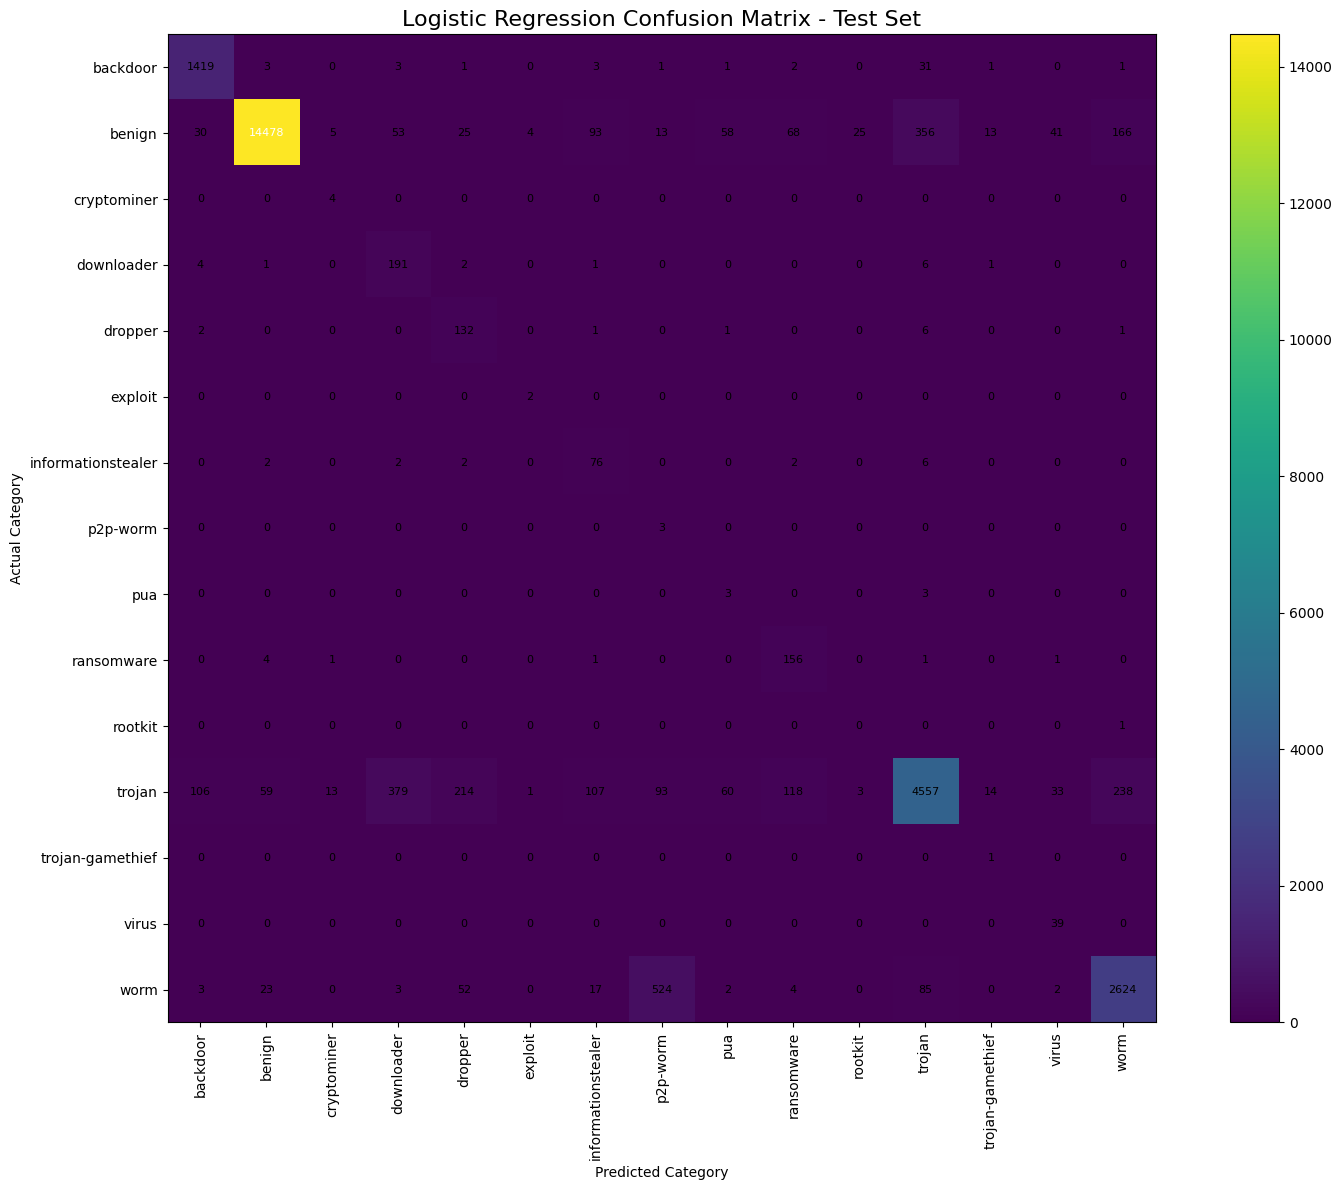

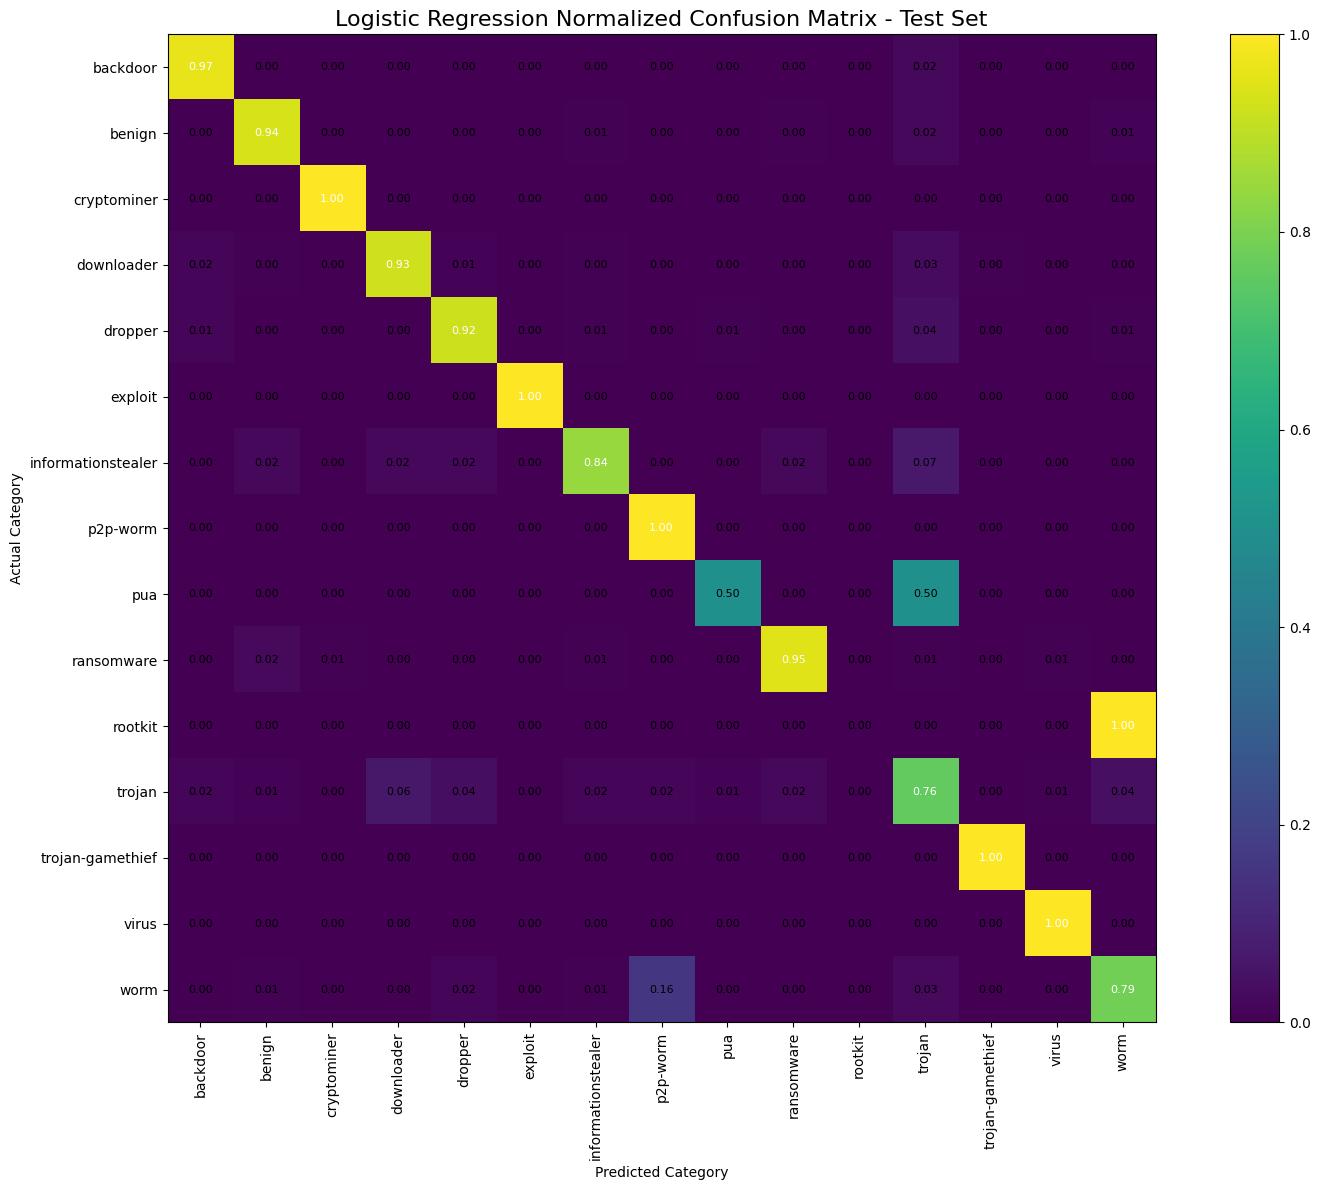

In [9]:
# ============================================================
# CONFUSION MATRIX IMAGES
# ============================================================

def plot_confusion_matrix_image(y_true, y_pred, title, normalize=False):
    labels = np.arange(len(class_names))

    if normalize:
        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=labels,
            normalize="true"
        )
        fmt = ".2f"
    else:
        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=labels
        )
        fmt = "d"

    plt.figure(figsize=(16, 12))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title, fontsize=16)
    plt.colorbar()

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=90)
    plt.yticks(tick_marks, class_names)

    threshold = cm.max() / 2

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = format(cm[i, j], fmt)
            plt.text(
                j,
                i,
                value,
                ha="center",
                va="center",
                color="white" if cm[i, j] > threshold else "black",
                fontsize=8
            )

    plt.ylabel("Actual Category")
    plt.xlabel("Predicted Category")
    plt.tight_layout()
    plt.show()


# Test set confusion matrix
plot_confusion_matrix_image(
    y_test,
    lr_test_results["predictions"],
    "Logistic Regression Confusion Matrix - Test Set",
    normalize=False
)

# Normalized test set confusion matrix
plot_confusion_matrix_image(
    y_test,
    lr_test_results["predictions"],
    "Logistic Regression Normalized Confusion Matrix - Test Set",
    normalize=True
)

## Sample Prediction Check

A sanity check on 30 randomly selected samples from the full dataset. This verifies the model produces sensible predictions on individual examples and confirms the label encoder round-trips correctly between integer indices and class name strings.

In [10]:
# ============================================================
# CHECKING LOGISTIC REGRESSION ON REAL SAMPLE ROWS
# ============================================================

N_SAMPLES = 30
rng = np.random.default_rng(RANDOM_STATE)

sample_indices = rng.choice(X.shape[0], size=N_SAMPLES, replace=False)

X_sample = X[sample_indices]
y_sample_true = y[sample_indices]

lr_sample_pred = lr_final.predict(X_sample)

sample_results = pd.DataFrame({
    "sample_index": sample_indices,
    "sha": df.iloc[sample_indices][metadata_sha_col].values,
    "actual_category": label_encoder.inverse_transform(y_sample_true),
    "predicted_category": label_encoder.inverse_transform(lr_sample_pred),
})

sample_results["correct"] = (
    sample_results["actual_category"] == sample_results["predicted_category"]
)

display(sample_results)

sample_accuracy = accuracy_score(y_sample_true, lr_sample_pred)

print("Logistic Regression accuracy on selected samples:", round(sample_accuracy, 4))
print("Correct predictions:", sample_results["correct"].sum(), "/", N_SAMPLES)

,sample_index,sha,actual_category,predicted_category,correct
0,86555,f61e47ff46c2029eb735df3d1eb6243196d4421c4ddc77...,benign,benign,True
1,70767,37f04f611715c86b6225faa7db02078f678a1ab086795b...,trojan,trojan,True
2,58201,8eb1bc75eea45ab42df04f28f80865bb5d8fa2c7d87e41...,worm,worm,True
3,115405,792d9e48ead3ace6282e25877450e9bda0bdedd066d93e...,benign,benign,True
4,11995,62ac3e52f1645ad2f35c3024b528f1f2902129221aef48...,benign,benign,True
5,12658,7a56ddb4e7fcc728286dc2d9dafcc0b869a50762b7d579...,benign,benign,True
6,24539,8e0ddde2f1456dc3f4bb5fa7d27a6c95d61726e67f8872...,trojan,trojan,True
7,110606,fb35b311e6ab34db6748d605662114cbd20e5eefb5522b...,benign,benign,True
8,105663,f15d7d9fe1f17214735eaae84df7b2f242199255d0367c...,benign,benign,True
9,93735,535582b8385115e6f8fd963de93f3fad4e70e66c5dc047...,benign,benign,True


Logistic Regression accuracy on selected samples: 0.8667
Correct predictions: 26 / 30


## Holdout Dataset Evaluation

The trained Logistic Regression model and label encoder are loaded from disk. The holdout dataset is an entirely separate set of samples not seen during training or tuning.

Label preparation follows the same logic as training - SHA256 join with benign fill. A validation check raises an error if any holdout class was not present during training, preventing silent mismatch errors.

Results on the holdout set reflect real-world generalisation performance.

LR model: /content/drive/MyDrive/BODMAS_Assignment/logisticregression/logistic_regression_model.joblib
Label encoder: /content/drive/MyDrive/BODMAS_Assignment/logisticregression/label_encoder.joblib
Holdout NPZ: /content/drive/MyDrive/BODMAS_Assignment/HoldOutDataSet/bodmas_holdout.npz

Logistic Regression model loaded.
Classes: ['backdoor', 'benign', 'cryptominer', 'downloader', 'dropper', 'exploit', 'informationstealer', 'p2p-worm', 'pua', 'ransomware', 'rootkit', 'trojan', 'trojan-gamethief', 'virus', 'worm']

Holdout X shape: (34435, 2381)
Holdout metadata shape: (34435, 3)
Holdout category shape: (57293, 2)

Holdout class distribution:


,count
benign,18363
trojan,6724
worm,6145
backdoor,2666
informationstealer,217
dropper,135
ransomware,105
downloader,55
p2p-worm,13
pua,9



Encoded holdout y shape: (34435,)

Running Logistic Regression on holdout dataset...

LOGISTIC REGRESSION HOLDOUT RESULTS
Overall Accuracy: 0.9096
Balanced Accuracy: 0.9513

Classification Report:
                    precision    recall  f1-score   support

          backdoor       0.94      0.97      0.96      2666
            benign       1.00      0.97      0.98     18363
       cryptominer       0.08      1.00      0.15         1
        downloader       0.23      0.95      0.37        55
           dropper       0.38      0.98      0.55       135
           exploit       0.00      0.00      0.00         0
informationstealer       0.63      0.99      0.77       217
          p2p-worm       0.01      1.00      0.02        13
               pua       0.03      1.00      0.05         9
        ransomware       0.45      0.94      0.61       105
           rootkit       0.00      0.00      0.00         0
            trojan       0.94      0.80      0.87      6724
  trojan-gamethief   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,class,TP,FP,TN,FN,TPR,FPR
0,backdoor,2593,167,31602,73,0.972618,0.005257
1,benign,17814,84,15988,549,0.970103,0.005226
2,cryptominer,1,11,34423,0,1.000000,0.000319
3,downloader,52,171,34209,3,0.945455,0.004974
4,dropper,132,211,34089,3,0.977778,0.006152
5,exploit,0,1,34434,0,0.000000,0.000029
6,informationstealer,215,125,34093,2,0.990783,0.003653
7,p2p-worm,13,1105,33317,0,1.000000,0.032102
8,pua,9,334,34092,0,1.000000,0.009702
9,ransomware,99,121,34209,6,0.942857,0.003525


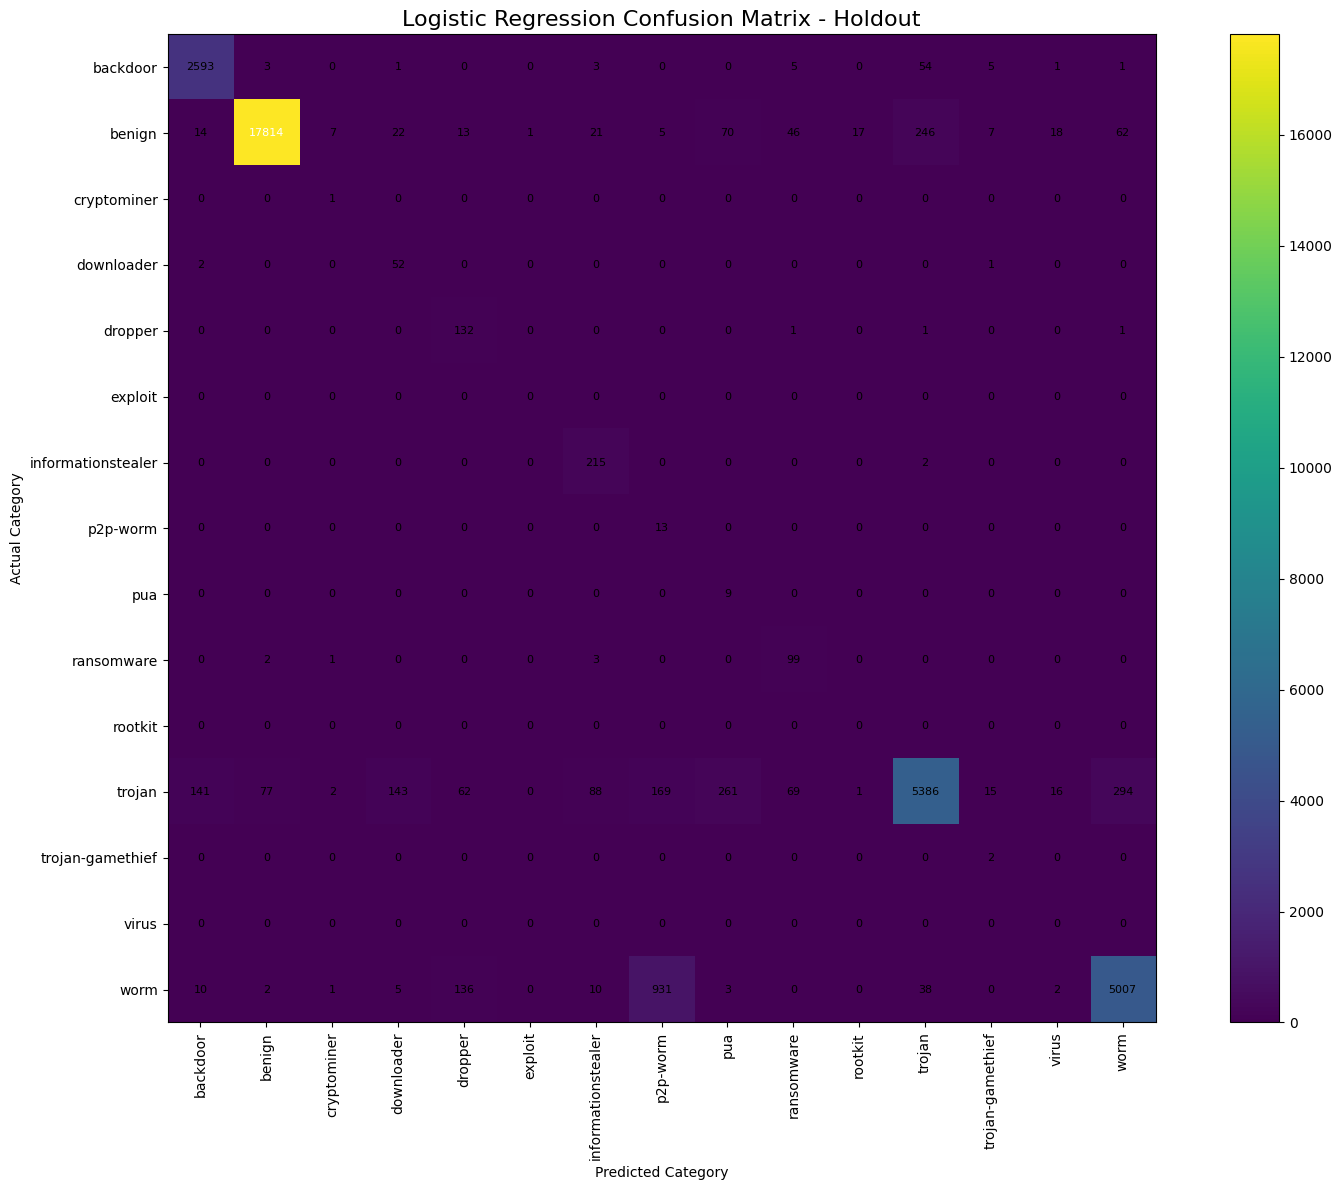

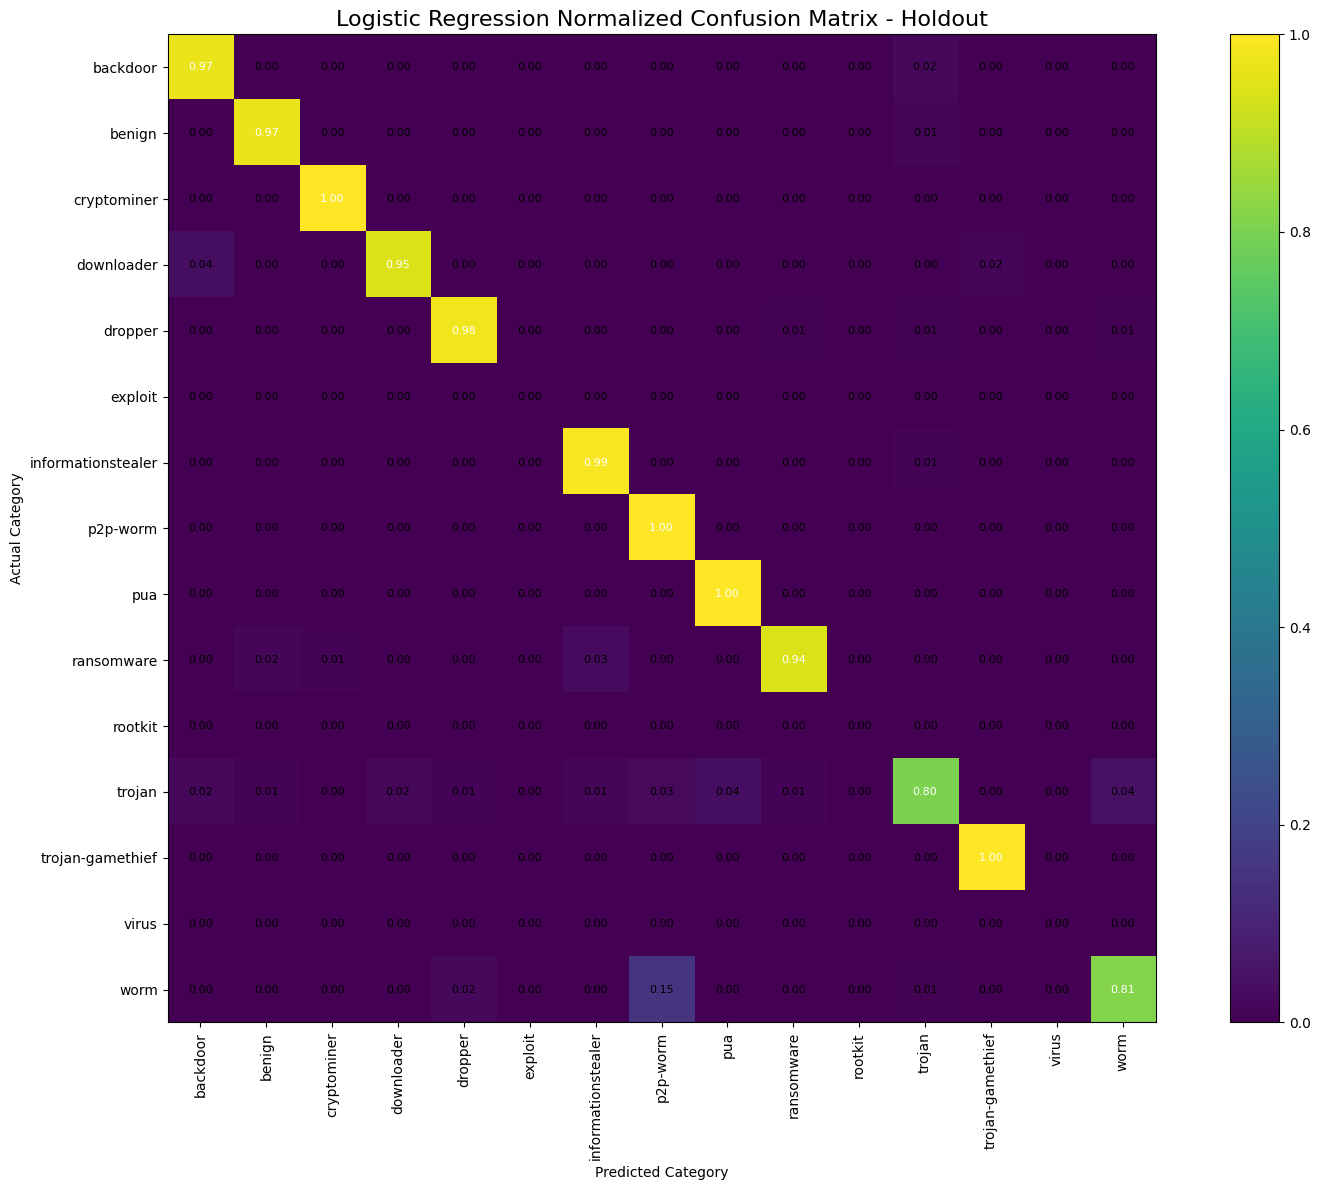

In [ ]:
# ============================================================
# LOGISTIC REGRESSION - HOLDOUT DATASET EVALUATION
# ============================================================

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix
)

PROJECT_DIR = "/content/drive/MyDrive/BODMAS_Assignment"

# PROJECT_DIR = ""

HOLDOUT_DIR = os.path.join(PROJECT_DIR, "HoldOutDataSet")
LR_DIR = os.path.join(PROJECT_DIR, "logisticregression")

HOLDOUT_NPZ = os.path.join(HOLDOUT_DIR, "bodmas_holdout.npz")
HOLDOUT_METADATA_CSV = os.path.join(HOLDOUT_DIR, "bodmas_metadata_holdout.csv")
HOLDOUT_CATEGORY_CSV = os.path.join(HOLDOUT_DIR, "bodmas_malware_category.csv")

LR_MODEL_PATH = os.path.join(LR_DIR, "logistic_regression_model.joblib")
LABEL_ENCODER_PATH = os.path.join(LR_DIR, "label_encoder.joblib")

print("LR model:", LR_MODEL_PATH)
print("Label encoder:", LABEL_ENCODER_PATH)
print("Holdout NPZ:", HOLDOUT_NPZ)

# ============================================================
# LOAD TRAINED LOGISTIC REGRESSION MODEL
# ============================================================

lr_model = joblib.load(LR_MODEL_PATH)
label_encoder = joblib.load(LABEL_ENCODER_PATH)

class_names = list(label_encoder.classes_)

print("\nLogistic Regression model loaded.")
print("Classes:", class_names)

# ============================================================
# LOAD HOLDOUT DATA
# ============================================================

holdout_data = np.load(HOLDOUT_NPZ, allow_pickle=True)
X_holdout = holdout_data["X"]

holdout_metadata = pd.read_csv(HOLDOUT_METADATA_CSV)
holdout_categories = pd.read_csv(HOLDOUT_CATEGORY_CSV)

print("\nHoldout X shape:", X_holdout.shape)
print("Holdout metadata shape:", holdout_metadata.shape)
print("Holdout category shape:", holdout_categories.shape)

# ============================================================
# PREPARE HOLDOUT CATEGORY LABELS
# ============================================================

metadata_sha_col = "sha256" if "sha256" in holdout_metadata.columns else "sha"
category_sha_col = "sha256" if "sha256" in holdout_categories.columns else "sha"

category_label_col = [
    c for c in holdout_categories.columns
    if c.lower() not in ["sha", "sha256"]
][0]

category_map = holdout_categories.set_index(category_sha_col)[category_label_col]

holdout_df = holdout_metadata.copy()
holdout_df["malware_category"] = holdout_df[metadata_sha_col].map(category_map)

# Missing category means benign
holdout_df["malware_category"] = holdout_df["malware_category"].fillna("benign")

y_holdout_text = holdout_df["malware_category"].astype(str).values

print("\nHoldout class distribution:")
display(pd.Series(y_holdout_text).value_counts())

# Checking unknown labels
unknown_classes = set(y_holdout_text) - set(class_names)

if unknown_classes:
    raise ValueError(f"Unknown classes in holdout not seen during training: {unknown_classes}")

y_holdout = label_encoder.transform(y_holdout_text)

print("\nEncoded holdout y shape:", y_holdout.shape)

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def calculate_tpr_fpr(y_true, y_pred, class_names):
    labels = np.arange(len(class_names))
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    rows = []

    for i, class_name in enumerate(class_names):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - TP - FN - FP

        TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
        FPR = FP / (FP + TN) if (FP + TN) > 0 else 0

        rows.append({
            "class": class_name,
            "TP": TP,
            "FP": FP,
            "TN": TN,
            "FN": FN,
            "TPR": TPR,
            "FPR": FPR
        })

    return pd.DataFrame(rows)


def plot_confusion_matrix_image(y_true, y_pred, title, normalize=False):
    labels = np.arange(len(class_names))

    if normalize:
        cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")
        fmt = ".2f"
    else:
        cm = confusion_matrix(y_true, y_pred, labels=labels)
        fmt = "d"

    plt.figure(figsize=(16, 12))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title, fontsize=16)
    plt.colorbar()

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=90)
    plt.yticks(tick_marks, class_names)

    threshold = cm.max() / 2 if cm.max() > 0 else 0

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j,
                i,
                format(cm[i, j], fmt),
                ha="center",
                va="center",
                color="white" if cm[i, j] > threshold else "black",
                fontsize=8
            )

    plt.ylabel("Actual Category")
    plt.xlabel("Predicted Category")
    plt.tight_layout()
    plt.show()

# ============================================================
# LOGISTIC REGRESSION HOLDOUT PREDICTION
# ============================================================

print("\nRunning Logistic Regression on holdout dataset...")

lr_pred = lr_model.predict(X_holdout)

lr_accuracy = accuracy_score(y_holdout, lr_pred)
lr_balanced_accuracy = balanced_accuracy_score(y_holdout, lr_pred)

print("\n" + "=" * 80)
print("LOGISTIC REGRESSION HOLDOUT RESULTS")
print("=" * 80)

print("Overall Accuracy:", round(lr_accuracy, 4))
print("Balanced Accuracy:", round(lr_balanced_accuracy, 4))

print("\nClassification Report:")
print(classification_report(
    y_holdout,
    lr_pred,
    labels=np.arange(len(class_names)),
    target_names=class_names,
    zero_division=0
))

lr_tpr_fpr = calculate_tpr_fpr(y_holdout, lr_pred, class_names)

print("\nTPR and FPR per class:")
display(lr_tpr_fpr)

# Confusion matrix images
plot_confusion_matrix_image(
    y_holdout,
    lr_pred,
    "Logistic Regression Confusion Matrix - Holdout",
    normalize=False
)

plot_confusion_matrix_image(
    y_holdout,
    lr_pred,
    "Logistic Regression Normalized Confusion Matrix - Holdout",
    normalize=True
)